# Phase 3: Recommendation System

In this notebook, you will:
1. Build a content-based filtering system using property features
2. Implement collaborative filtering (user-based and item-based)
3. Create a hybrid recommendation system
4. Evaluate recommendation quality

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.recommendation import *

## 1. Data Preparation

In [11]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Properties: {X_scaled.shape[0]}, Features: {X_scaled.shape[1]}")

Properties: 20640, Features: 8


## 2. Content-Based Filtering

Similarity matrix shape: (20640, 20640)
Recommendations for property index 0:
Property Index: 17159, Distance: 0.4470
Property Index: 1635, Distance: 0.4993
Property Index: 18321, Distance: 0.5744
Property Index: 9401, Distance: 0.6389
Property Index: 18286, Distance: 0.6446


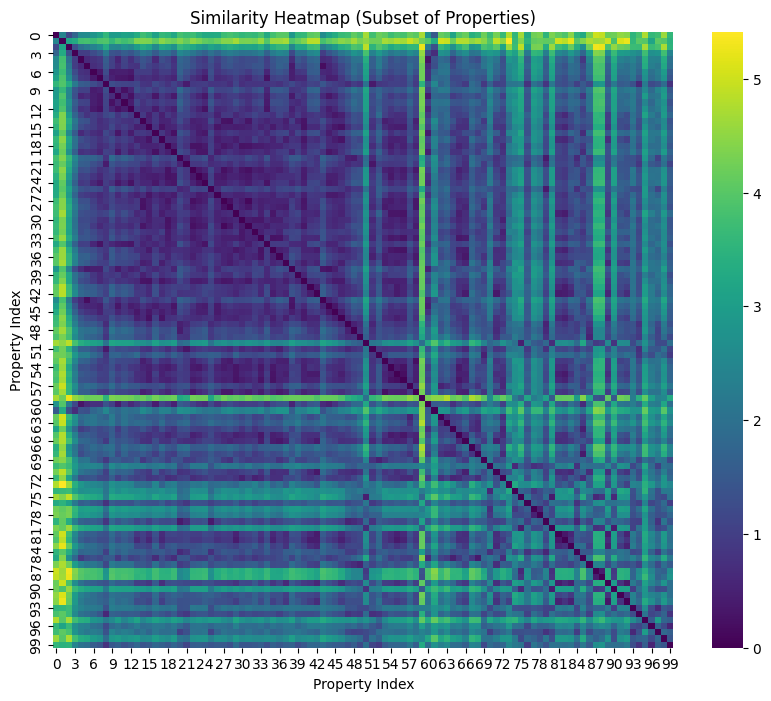

In [12]:
from sklearn.metrics.pairwise import pairwise_distances

# TODO: Compute similarity matrix
# TODO: Get recommendations for a sample property
# TODO: Visualize similarity heatmap (use a subset)


similarity_matrix = pairwise_distances(X_scaled, metric='euclidean')
print("Similarity matrix shape:", similarity_matrix.shape)

# Get recommendations for a sample property (e.g., index 0)
recommendations = knn_recommend(X_scaled, property_index=0, n_recommendations=5, metric='euclidean')
print("Recommendations for property index 0:")
for rec in recommendations:
    print(f"Property Index: {rec['property_index']}, Distance: {rec['distance']:.4f}")  

# Visualize similarity heatmap for a subset of properties
subset_size = 100
subset_similarity = similarity_matrix[:subset_size, :subset_size]
plt.figure(figsize=(10, 8))
sns.heatmap(subset_similarity, cmap='viridis')
plt.title('Similarity Heatmap (Subset of Properties)')
plt.xlabel('Property Index')
plt.ylabel('Property Index')
plt.show()

In [13]:
# TODO: Use KNN-based recommendations
# Compare with cosine similarity recommendations
knn_recommendations = knn_recommend(X_scaled, property_index=0, n_recommendations=5, metric='euclidean')
print("KNN Recommendations for property index 0:")
for rec in knn_recommendations:
    print(f"Property Index: {rec['property_index']}, Distance: {rec['distance']:.4f}")

#Compare with cosine similarity recommendations
cosine_recommendations = knn_recommend(X_scaled, property_index=0, n_recommendations=5, metric='cosine')
print("Cosine Similarity Recommendations for property index 0:")
for rec in cosine_recommendations:
    print(f"Property Index: {rec['property_index']}, Similarity: {rec['distance']:.4f}")


KNN Recommendations for property index 0:
Property Index: 17159, Distance: 0.4470
Property Index: 1635, Distance: 0.4993
Property Index: 18321, Distance: 0.5744
Property Index: 9401, Distance: 0.6389
Property Index: 18286, Distance: 0.6446
Cosine Similarity Recommendations for property index 0:
Property Index: 1635, Similarity: 0.0069
Property Index: 17159, Similarity: 0.0071
Property Index: 18321, Similarity: 0.0084
Property Index: 18276, Similarity: 0.0087
Property Index: 18359, Similarity: 0.0090


## 3. Collaborative Filtering

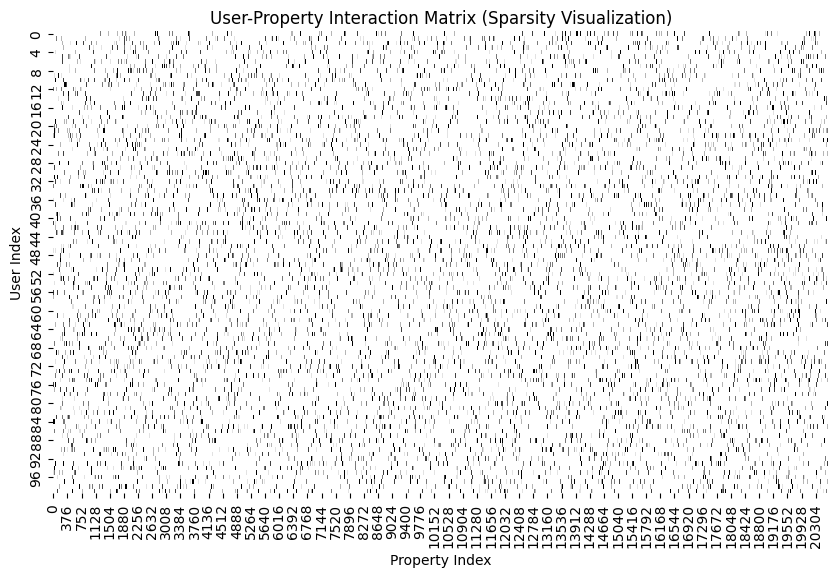

In [14]:
# TODO: Create user-property interaction matrix
# Visualize sparsity pattern
user_property_matrix = create_user_property_matrix(n_users=100, n_properties=X_scaled.shape[0], sparsity=0.9, random_state=42)
plt.figure(figsize=(10, 6))
sns.heatmap(user_property_matrix, cmap='Greys', cbar=False)
plt.title('User-Property Interaction Matrix (Sparsity Visualization)')
plt.xlabel('Property Index')
plt.ylabel('User Index')
plt.show()



In [15]:
# TODO: User-based collaborative filtering
# Get recommendations for sample users
user_recommendations = user_based_collaborative_filter(user_property_matrix, user_index=0, n_recommendations=5)
print("User-Based Collaborative Filtering Recommendations for user index 0:")
for rec in user_recommendations:
    print(f"Property Index: {rec['property_index']}, Predicted Rating: {rec['predicted_rating']:.4f}")


User-Based Collaborative Filtering Recommendations for user index 0:
Property Index: 5891, Predicted Rating: 2.0116
Property Index: 20313, Predicted Rating: 1.9774
Property Index: 10038, Predicted Rating: 1.9074
Property Index: 20355, Predicted Rating: 1.8985
Property Index: 6875, Predicted Rating: 1.8332


In [16]:
# TODO: Item-based collaborative filtering
# Compare with user-based results
item_recommendations = item_based_collaborative_filter(user_property_matrix, user_index=0, n_recommendations=5)
print("Item-Based Collaborative Filtering Recommendations for user index 0:")
for rec in item_recommendations:
    print(f"Property Index: {rec['property_index']}, Predicted Rating: {rec['predicted_rating']:.4f}")

Item-Based Collaborative Filtering Recommendations for user index 0:
Property Index: 11605, Predicted Rating: 3.1102
Property Index: 10342, Predicted Rating: 3.0941
Property Index: 11467, Predicted Rating: 3.0900
Property Index: 3446, Predicted Rating: 3.0817
Property Index: 12318, Predicted Rating: 3.0781


## 4. Hybrid Recommendation System

In [17]:
# TODO: Build hybrid recommender
# Experiment with different content_weight / collaborative_weight

## 5. Evaluation

In [18]:
# TODO: Evaluate each recommendation approach
# Compare precision/recall across methods

## Summary

TODO: Write a summary:
- Which approach produced the most relevant recommendations?
- How did the hybrid system compare to individual approaches?
- What are the limitations of each method for real estate?